Code-only notebook. All explanations, derivations and result interpretations: `13_project_report.ipynb`, section "Notebook 09 - Correlated noise and cause diagnosis".

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from qsv.data_generation import create_dataset, create_multiclass_dataset
from qsv.features import add_correlated_noise, compute_features, sigma_from_shots

RANDOM_STATE = 42
%matplotlib inline
print("Environment ready")

Environment ready


rho=0.0 | threshold test: 0.9164 | Random Forest: 0.9152


rho=0.5 | threshold test: 0.9156 | Random Forest: 0.9116


rho=0.9 | threshold test: 0.9104 | Random Forest: 0.9124


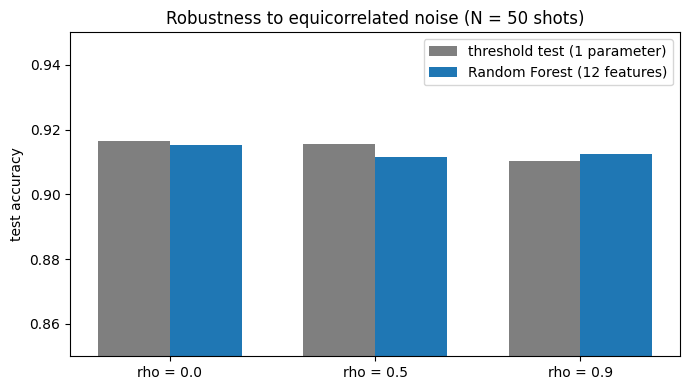

In [2]:
DIM, N = 4, 50
sigma = sigma_from_shots(N)
df = create_dataset(5000, 5000, dim=DIM, seed=RANDOM_STATE)

results_a = {}
for rho in (0.0, 0.5, 0.9):
    d = add_correlated_noise(df, n_shots=N, rho=rho, seed=RANDOM_STATE)
    y = d["is_valid"]
    stat = np.abs(d["norm_squared"] - 1.0 - 2 * DIM * sigma**2).to_frame("t_stat")
    X = pd.concat(
        [d[[c for c in d.columns if c.startswith("c")]],
         compute_features(d, kind="all")], axis=1)

    X_tr, X_te, s_tr, s_te, y_tr, y_te = train_test_split(
        X, stat, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

    stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
    stump.fit(s_tr, y_tr)
    rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_tr, y_tr)

    results_a[rho] = {
        "threshold": accuracy_score(y_te, stump.predict(s_te)),
        "rf": accuracy_score(y_te, rf.predict(X_te)),
    }
    print(f"rho={rho:.1f} | threshold test: {results_a[rho]['threshold']:.4f} | "
          f"Random Forest: {results_a[rho]['rf']:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
rhos = list(results_a)
w = 0.35
ax.bar([r - w/2 for r in range(3)], [results_a[r]["threshold"] for r in rhos],
       width=w, label="threshold test (1 parameter)", color="tab:gray")
ax.bar([r + w/2 for r in range(3)], [results_a[r]["rf"] for r in rhos],
       width=w, label="Random Forest (12 features)", color="tab:blue")
ax.set_xticks(range(3)); ax.set_xticklabels([f"rho = {r}" for r in rhos])
ax.set_ylim(0.85, 0.95); ax.set_ylabel("test accuracy")
ax.set_title(f"Robustness to equicorrelated noise (N = {N} shots)")
ax.legend(); plt.tight_layout(); plt.show()

{'valid': 4000, 'scaling': 1000, 'extreme': 1000, 'noise': 1000, 'direct': 1000}



Random Forest (12 features)   : 0.8990
Tree on the norm alone (1D)   : 0.8950


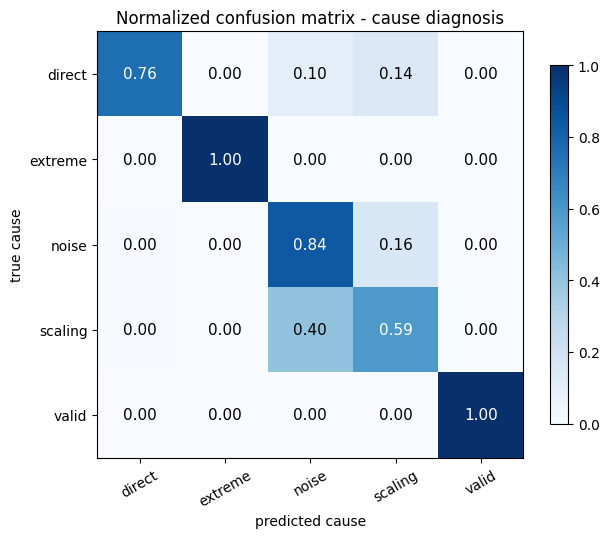

In [3]:
mc = create_multiclass_dataset(n_valid=4000, n_per_cause=1000, dim=DIM, seed=RANDOM_STATE)
print(mc["cause"].value_counts().to_dict())

X = pd.concat(
    [mc[[c for c in mc.columns if c.startswith("c") and c != "cause"]],
     compute_features(mc, kind="all")], axis=1)
y = mc["cause"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_tr, y_tr)
acc_rf = accuracy_score(y_te, rf.predict(X_te))

tree_norm = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
tree_norm.fit(X_tr[["norm_squared"]], y_tr)
acc_norm = accuracy_score(y_te, tree_norm.predict(X_te[["norm_squared"]]))

print(f"\nRandom Forest (12 features)   : {acc_rf:.4f}")
print(f"Tree on the norm alone (1D)   : {acc_norm:.4f}")

labels = sorted(y.unique())
cm = confusion_matrix(y_te, rf.predict(X_te), labels=labels, normalize="true")
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=30)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                color="white" if cm[i, j] > 0.5 else "black", fontsize=11)
ax.set_xlabel("predicted cause"); ax.set_ylabel("true cause")
ax.set_title("Normalized confusion matrix - cause diagnosis")
plt.colorbar(im, shrink=0.8); plt.tight_layout(); plt.show()

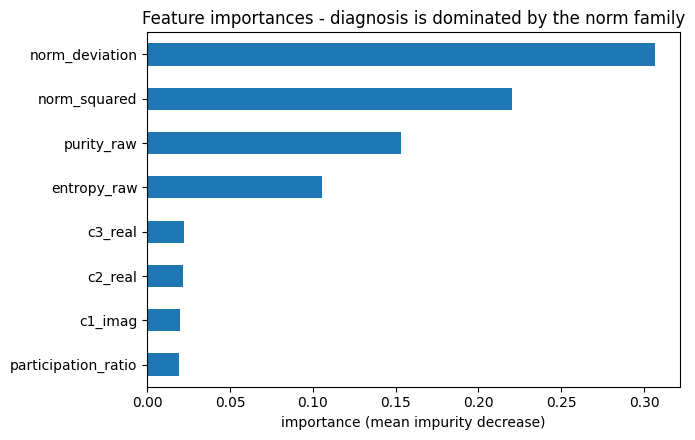

entropy_raw       0.105
purity_raw        0.153
norm_squared      0.220
norm_deviation    0.306


In [4]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5))
imp.tail(8).plot.barh(ax=ax, color="tab:blue")
ax.set_title("Feature importances - diagnosis is dominated by the norm family")
ax.set_xlabel("importance (mean impurity decrease)")
plt.tight_layout(); plt.show()
print(imp.tail(4).round(3).to_string())